In [2]:
import os
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import face_recognition
import pickle

In [3]:
class FacePreprocessor:
    def __init__(self, target_size=(160, 160)):
        """
        Args:
            target_size: Output size of the face image (width, height)
        """
        self.target_size = target_size
    
    def normalize_illumination(self, image):
        """
        Apply Gamma Correction + CLAHE to fix lighting issues (shadows/glare).
        """
        gamma = 1.2
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        gamma_corrected = cv.LUT(image, table)

        lab = cv.cvtColor(gamma_corrected, cv.COLOR_BGR2LAB)
        l, a, b = cv.split(lab)

        clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)

        limg = cv.merge((cl, a, b))
        final_image = cv.cvtColor(limg, cv.COLOR_LAB2BGR)
        
        return final_image
    
    def denoise_image(self, image):
        """
        Remove noise from image before face detection
        """
        denoised = cv.fastNlMeansDenoisingColored(
            image, 
            None, 
            h=10,           # Filter strength for luminance
            hColor=10,      # Filter strength for color
            templateWindowSize=7, 
            searchWindowSize=21
        )
        return denoised
    
    def align_face(self, image, face_location):
        """
        Align face by rotating based on eye positions
        
        Args:
            image: Input image
            face_location: Single face location tuple (top, right, bottom, left)
        
        Returns:
            aligned_face: Rotated and aligned face
        """
        # Handle if list is passed instead of tuple
        if isinstance(face_location, list):
            if len(face_location) == 0:
                return image
            face_location = face_location[0]
        
        # Validate face_location is a tuple with 4 elements
        if not isinstance(face_location, tuple) or len(face_location) != 4:
            return image
        
        try:
            face_landmarks = face_recognition.face_landmarks(image, [face_location])
            
            if len(face_landmarks) > 0:
                landmarks = face_landmarks[0]
                
                # Check if eyes exist in landmarks
                if 'left_eye' not in landmarks or 'right_eye' not in landmarks:
                    return image
                
                left_eye = landmarks['left_eye']
                right_eye = landmarks['right_eye']
                
                left_eye_center = np.mean(left_eye, axis=0).astype(int)
                right_eye_center = np.mean(right_eye, axis=0).astype(int)
                
                dy = right_eye_center[1] - left_eye_center[1]
                dx = right_eye_center[0] - left_eye_center[0]
                angle = np.degrees(np.arctan2(dy, dx))
                
                top, right, bottom, left = face_location
                center = ((left + right) // 2, (top + bottom) // 2)
                
                rotation_matrix = cv.getRotationMatrix2D(center, angle, 1.0)
                aligned_image = cv.warpAffine(image, rotation_matrix, 
                                             (image.shape[1], image.shape[0]),
                                             flags=cv.INTER_CUBIC)
                
                return aligned_image
        except Exception as e:
            print(f"Alignment error: {e}")
        
        return image
    

    def crop_face(self, image, face_location):
        """Crop face from image based on face location"""
        top, right, bottom, left = face_location
        face_image = image[top:bottom, left:right]
        return face_image
    
    def resize_face(self, face_image):
        resized_face = cv.resize(face_image, self.target_size, interpolation=cv.INTER_CUBIC)
        return resized_face

    def process(self, image, face_location):
        """Main pipeline: Align -> Normalize"""
        # Handle if list is passed
        if isinstance(face_location, list):
            if len(face_location) == 0:
                return image
            face_location = face_location[0]
        
        # 1. Align (Geometric Normalization)
        aligned_face = self.align_face(image, face_location)
        
        # 2. Illumination Normalization
        processed_face = self.normalize_illumination(aligned_face)

        
        return processed_face
    
    

    @staticmethod
    def get_largest_face(face_locations):
        """Get the largest face from list of face locations"""
        if not face_locations:
            return []
        return [max(face_locations, key=lambda f: (f[2] - f[0]) * (f[1] - f[3]))]

In [4]:
def load_img_from_folder(folder_path):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    image_list = []
    filename_list = []

    for filename in os.listdir(folder_path):
        ext = os.path.splitext(filename)[1].lower()
        if ext in valid_extensions:
            img_path = os.path.join(folder_path, filename)
            img = cv.imread(img_path)
            if img is not None:
                image_list.append(img)
                filename_list.append(os.path.splitext(filename)[0])
            else:
                print(f"Warning: Unable to read image {img_path}")
    return image_list, filename_list

In [5]:
img_folder_path = "Image"
images, studentID_list = load_img_from_folder(img_folder_path)
print(f"Loaded {len(images)} faces")

Loaded 33 faces


In [6]:
def pipeline_face_registration(face_img, preprocessor: FacePreprocessor, detection_model = "hog"):
    successful = False
    
    # Hog Detection
    denoised_face = preprocessor.denoise_image(face_img)
    rgb_face = cv.cvtColor(denoised_face, cv.COLOR_BGR2RGB)
    face_locations = face_recognition.face_locations(rgb_face, model=detection_model)
    processed_face = preprocessor.process(rgb_face, face_locations)
    # Extract 128D encoding by dlib algorithm
    encodings = face_recognition.face_encodings(processed_face, model = "small", known_face_locations=face_locations)
    if len(encodings) > 0:
        successful = True
        print(" Success")
        
    else:
        print(" Failed")
        successful = False
    return encodings[0], successful
    

In [7]:
list_known_encoding_fr = []
list_reg_student_id = []
countSuccess = 0
preprocessor = FacePreprocessor(target_size=(260, 260))
for idx, (face_img, id) in enumerate(zip(images, studentID_list)):
    print(f"Processing [{idx+1}/{len(images)}] {id}...", end=" ")
    encoding, successful = pipeline_face_registration(face_img, preprocessor, detection_model = "hog")
    if successful:
        list_known_encoding_fr.append(encoding)
        list_reg_student_id.append(id)
        countSuccess += 1

print(f"Registered {countSuccess}/{len(images)} faces successfully.")


Processing [1/33] 23WMA06667...  Success
Processing [2/33] 23WMA09991...  Success
Processing [3/33] 23WMA09992...  Success
Processing [4/33] 23WMA09993...  Success
Processing [5/33] 23WMA09994...  Success
Processing [6/33] 23WMA09998...  Success
Processing [7/33] 23WMA31290...  Success
Processing [8/33] 24WMR00272...  Success
Processing [9/33] 24WMR06014...  Success
Processing [10/33] 24WMR06069...  Success
Processing [11/33] 24WMR07001...  Success
Processing [12/33] 24WMR07039...  Success
Processing [13/33] 24WMR07055...  Success
Processing [14/33] 24WMR07058...  Success
Processing [15/33] 24WMR07088...  Success
Processing [16/33] 24WMR07090...  Success
Processing [17/33] 24WMR07110...  Success
Processing [18/33] 24WMR07123...  Success
Processing [19/33] 24WMR07578...  Success
Processing [20/33] 24WMR07983...  Success
Processing [21/33] 24WMR08000...  Success
Processing [22/33] 24WMR08003...  Success
Processing [23/33] 24WMR08010...  Success
Processing [24/33] 24WMR08011...  Success
P

In [8]:
import pickle

def save_encodings(encodings, ids, filepath="fr_encodings.pkl"):
    """
    Save face encodings and IDs to a pickle file
    
    Args:
        encodings: List of face encodings (128D vectors)
        ids: List of student IDs
        filepath: Path to save the pickle file
    """
    data = {
        'encodings': encodings,
        'ids': ids,
        'count': len(ids)
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    
    print(f"Saved {len(ids)} face encodings to '{filepath}'")
    return filepath

In [10]:
save_encodings(list_known_encoding_fr, list_reg_student_id, filepath="encodings\\fr_encodings.pkl")

Saved 33 face encodings to 'encodings\fr_encodings.pkl'


'encodings\\fr_encodings.pkl'

In [11]:
## Create Test Scenarios (Blur, Noise, Brightness, etc.)

def create_test_scenarios(image):
    """
    Create different test scenarios from one image
    
    Returns: dict with scenario name and augmented image
    """
    scenarios = {}
    
    # 1. Original
    scenarios['original'] = image.copy()
    
    # 2. Gaussian Blur (simulates out-of-focus camera)
    scenarios['blur_light'] = cv.GaussianBlur(image, (5, 5), 0)
    scenarios['blur_medium'] = cv.GaussianBlur(image, (9, 9), 0)
    scenarios['blur_heavy'] = cv.GaussianBlur(image, (15, 15), 0)
    
    # 3. Motion Blur
    kernel_size = 15
    kernel_motion = np.zeros((kernel_size, kernel_size))
    kernel_motion[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel_motion = kernel_motion / kernel_size
    scenarios['motion_blur'] = cv.filter2D(image, -1, kernel_motion)
    
    # 4. Gaussian Noise
    noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
    scenarios['noise'] = cv.add(image, noise)
    
    # 5. Low Light (Dark)
    scenarios['low_light'] = cv.convertScaleAbs(image, alpha=0.5, beta=-30)
    
    # 6. High Light (Bright)
    scenarios['high_light'] = cv.convertScaleAbs(image, alpha=1.2, beta=30)
    
    # 7. Low Contrast
    scenarios['low_contrast'] = cv.convertScaleAbs(image, alpha=0.7, beta=0)
    
    # 8. High Contrast
    scenarios['high_contrast'] = cv.convertScaleAbs(image, alpha=1.5, beta=0)
    
    # 9. JPEG Compression artifacts
    encode_param = [int(cv.IMWRITE_JPEG_QUALITY), 20]  # Low quality
    _, encoded = cv.imencode('.jpg', image, encode_param)
    scenarios['jpeg_compressed'] = cv.imdecode(encoded, 1)
    
    # 10. Rotation (slight angle)
    h, w = image.shape[:2]
    M = cv.getRotationMatrix2D((w/2, h/2), 10, 1.0)
    scenarios['rotated_10'] = cv.warpAffine(image, M, (w, h))
    
    # 11. Zoomed (scale)
    M = cv.getRotationMatrix2D((w/2, h/2), 0, 1.2)
    scenarios['zoomed'] = cv.warpAffine(image, M, (w, h))
    
    # 12. Cropped Face (tight crop)
    rgb_img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    face_locations = face_recognition.face_locations(rgb_img, model="hog")
    if len(face_locations) > 0:
        top, right, bottom, left = face_locations[0]
        # Tight crop
        scenarios['cropped_tight'] = image[top:bottom, left:right].copy()
        
        # Crop with 50% padding
        face_h, face_w = bottom - top, right - left
        pad_h, pad_w = int(face_h * 0.1), int(face_w * 0.1)
        h, w = image.shape[:2]
        new_top = max(0, top + pad_h)
        new_bottom = min(h, bottom - pad_h)
        new_left = max(0, left + pad_w)
        new_right = min(w, right - pad_w)
        scenarios['cropped_padded'] = image[new_top:new_bottom, new_left:new_right].copy()
    
    return scenarios

In [12]:
test_img_list, type_test = load_img_from_folder("test_set/fz")
## Append All Scenarios to Test Lists
# Store original counts
original_count = len(test_img_list)

# Create new lists to store all scenarios
augmented_test_img_list = []
augmented_type_test = []

# For each test image, create scenarios and append
for img, img_name in zip(test_img_list, type_test):
    print(f"\nProcessing: {img_name}")
    
    # Create scenarios
    scenarios = create_test_scenarios(img)
    
    # Append each scenario to lists
    for scenario_name, scenario_img in scenarios.items():
        augmented_test_img_list.append(scenario_img)
        augmented_type_test.append(f"{img_name}_{scenario_name}")
    
    print(f"  → Created {len(scenarios)} scenarios")

print("\n" + "=" * 60)
print(f"✓ Original test images: {original_count}")
print(f"✓ Total test images (with scenarios): {len(augmented_test_img_list)}")
print(f"✓ Scenarios per image: {len(augmented_test_img_list) // original_count}")
print("=" * 60)

# Show sample names
print("\nSample augmented names:")
for i in range(min(15, len(augmented_type_test))):
    print(f"  {i+1}. {augmented_type_test[i]}")


Processing: 1_normal
  → Created 15 scenarios

Processing: 2_no_spec
  → Created 15 scenarios

✓ Original test images: 2
✓ Total test images (with scenarios): 30
✓ Scenarios per image: 15

Sample augmented names:
  1. 1_normal_original
  2. 1_normal_blur_light
  3. 1_normal_blur_medium
  4. 1_normal_blur_heavy
  5. 1_normal_motion_blur
  6. 1_normal_noise
  7. 1_normal_low_light
  8. 1_normal_high_light
  9. 1_normal_low_contrast
  10. 1_normal_high_contrast
  11. 1_normal_jpeg_compressed
  12. 1_normal_rotated_10
  13. 1_normal_zoomed
  14. 1_normal_cropped_tight
  15. 1_normal_cropped_padded


In [13]:
def process_face_recognition(face_locations, face_preprocessor: FacePreprocessor,face_img, known_encodings, known_ids, threshold=0.5):
    """
    Complete face recognition pipeline with error handling
    """
    try:
        # Check if any face detected
        if len(face_locations) == 0:
            return {
                'success': False,
                'pred_id': 'No Face Detected',
                'confidence': 0.0,
                'distance': None,
                'all_distances': []
            }
        
        # Preprocess face image
        preprocessed_face = face_preprocessor.process(face_img, face_locations)

        # Step 6: Extract encoding
        encodings = face_recognition.face_encodings(
            preprocessed_face,
            model="small",
            known_face_locations=face_locations
        )
        
        # Check if encoding extracted
        if len(encodings) == 0:
            return {
                'success': False,
                'pred_id': 'No Encoding',
                'confidence': 0.0,
                'distance': None,
                'all_distances': []
            }
        
        # Step 7: Compare with known faces
        distances = face_recognition.face_distance(known_encodings, encodings[0])
        matches = face_recognition.compare_faces(known_encodings, encodings[0], tolerance=threshold)
        
        # Step 8: Find best match
        if len(distances) > 0:
            min_distance = min(distances)
            min_idx = np.argmin(distances)
            
            # Check if match is within threshold
            if matches[min_idx] and min_distance < threshold:
                pred_id = known_ids[min_idx]
                confidence = 1 - min_distance
                success = True
            else:
                pred_id = "Unknown"
                confidence = 0.0
                success = False
        else:
            pred_id = "Unknown"
            min_distance = None
            confidence = 0.0
            success = False
        
        return {
            'success': success,
            'pred_id': pred_id,
            'confidence': confidence,
            'distance': min_distance,
            'all_distances': distances.tolist() if distances is not None else []
        }
    
    except Exception as e:
        # Catch any unexpected errors
        return {
            'success': False,
            'pred_id': f'Error: {str(e)}',
            'confidence': 0.0,
            'distance': None,
            'all_distances': []
        }

In [14]:
## Test Pipeline on All Scenarios

print("\n" + "=" * 60)
print("🧪 Testing Pipeline on All Scenarios")
print("=" * 60)

true_student_id = "24WMR08003"
all_results = []

for idx, (test_img, img_name) in enumerate(zip(augmented_test_img_list, augmented_type_test)):
    # Run recognition pipeline
    face_img = cv.cvtColor(test_img, cv.COLOR_BGR2RGB)
    processed_face = preprocessor.denoise_image(face_img)
    face_locations = face_recognition.face_locations(processed_face, model="hog")
    result = process_face_recognition(
        face_locations,
        preprocessor,
        processed_face,
        list_known_encoding_fr,
        list_reg_student_id,
        threshold=0.6
    )
    
    # Add metadata
    result['test_name'] = img_name
    result['true_id'] = true_student_id
    result['correct'] = (result['pred_id'] == true_student_id)
    
    all_results.append(result)
    
    # Display result
    status = "✓" if result['correct'] else "✗"
    dist_str = f"{result['distance']:.4f}" if result['distance'] is not None else "N/A"
    
    print(f"{status} [{idx+1:3d}] {img_name:40s} → {result['pred_id']:15s} "
          f"(Conf: {result['confidence']:.2%}, Dist: {dist_str})")

print("\n" + "=" * 60)


🧪 Testing Pipeline on All Scenarios
✓ [  1] 1_normal_original                        → 24WMR08003      (Conf: 50.05%, Dist: 0.4995)
✓ [  2] 1_normal_blur_light                      → 24WMR08003      (Conf: 49.11%, Dist: 0.5089)
✓ [  3] 1_normal_blur_medium                     → 24WMR08003      (Conf: 48.66%, Dist: 0.5134)
✓ [  4] 1_normal_blur_heavy                      → 24WMR08003      (Conf: 47.66%, Dist: 0.5234)
✓ [  5] 1_normal_motion_blur                     → 24WMR08003      (Conf: 50.99%, Dist: 0.4901)
✗ [  6] 1_normal_noise                           → No Face Detected (Conf: 0.00%, Dist: N/A)
✓ [  7] 1_normal_low_light                       → 24WMR08003      (Conf: 50.47%, Dist: 0.4953)
✓ [  8] 1_normal_high_light                      → 24WMR08003      (Conf: 50.64%, Dist: 0.4936)
✓ [  9] 1_normal_low_contrast                    → 24WMR08003      (Conf: 50.70%, Dist: 0.4930)
✓ [ 10] 1_normal_high_contrast                   → 24WMR08003      (Conf: 49.80%, Dist: 0.5020)
✓ [ 11

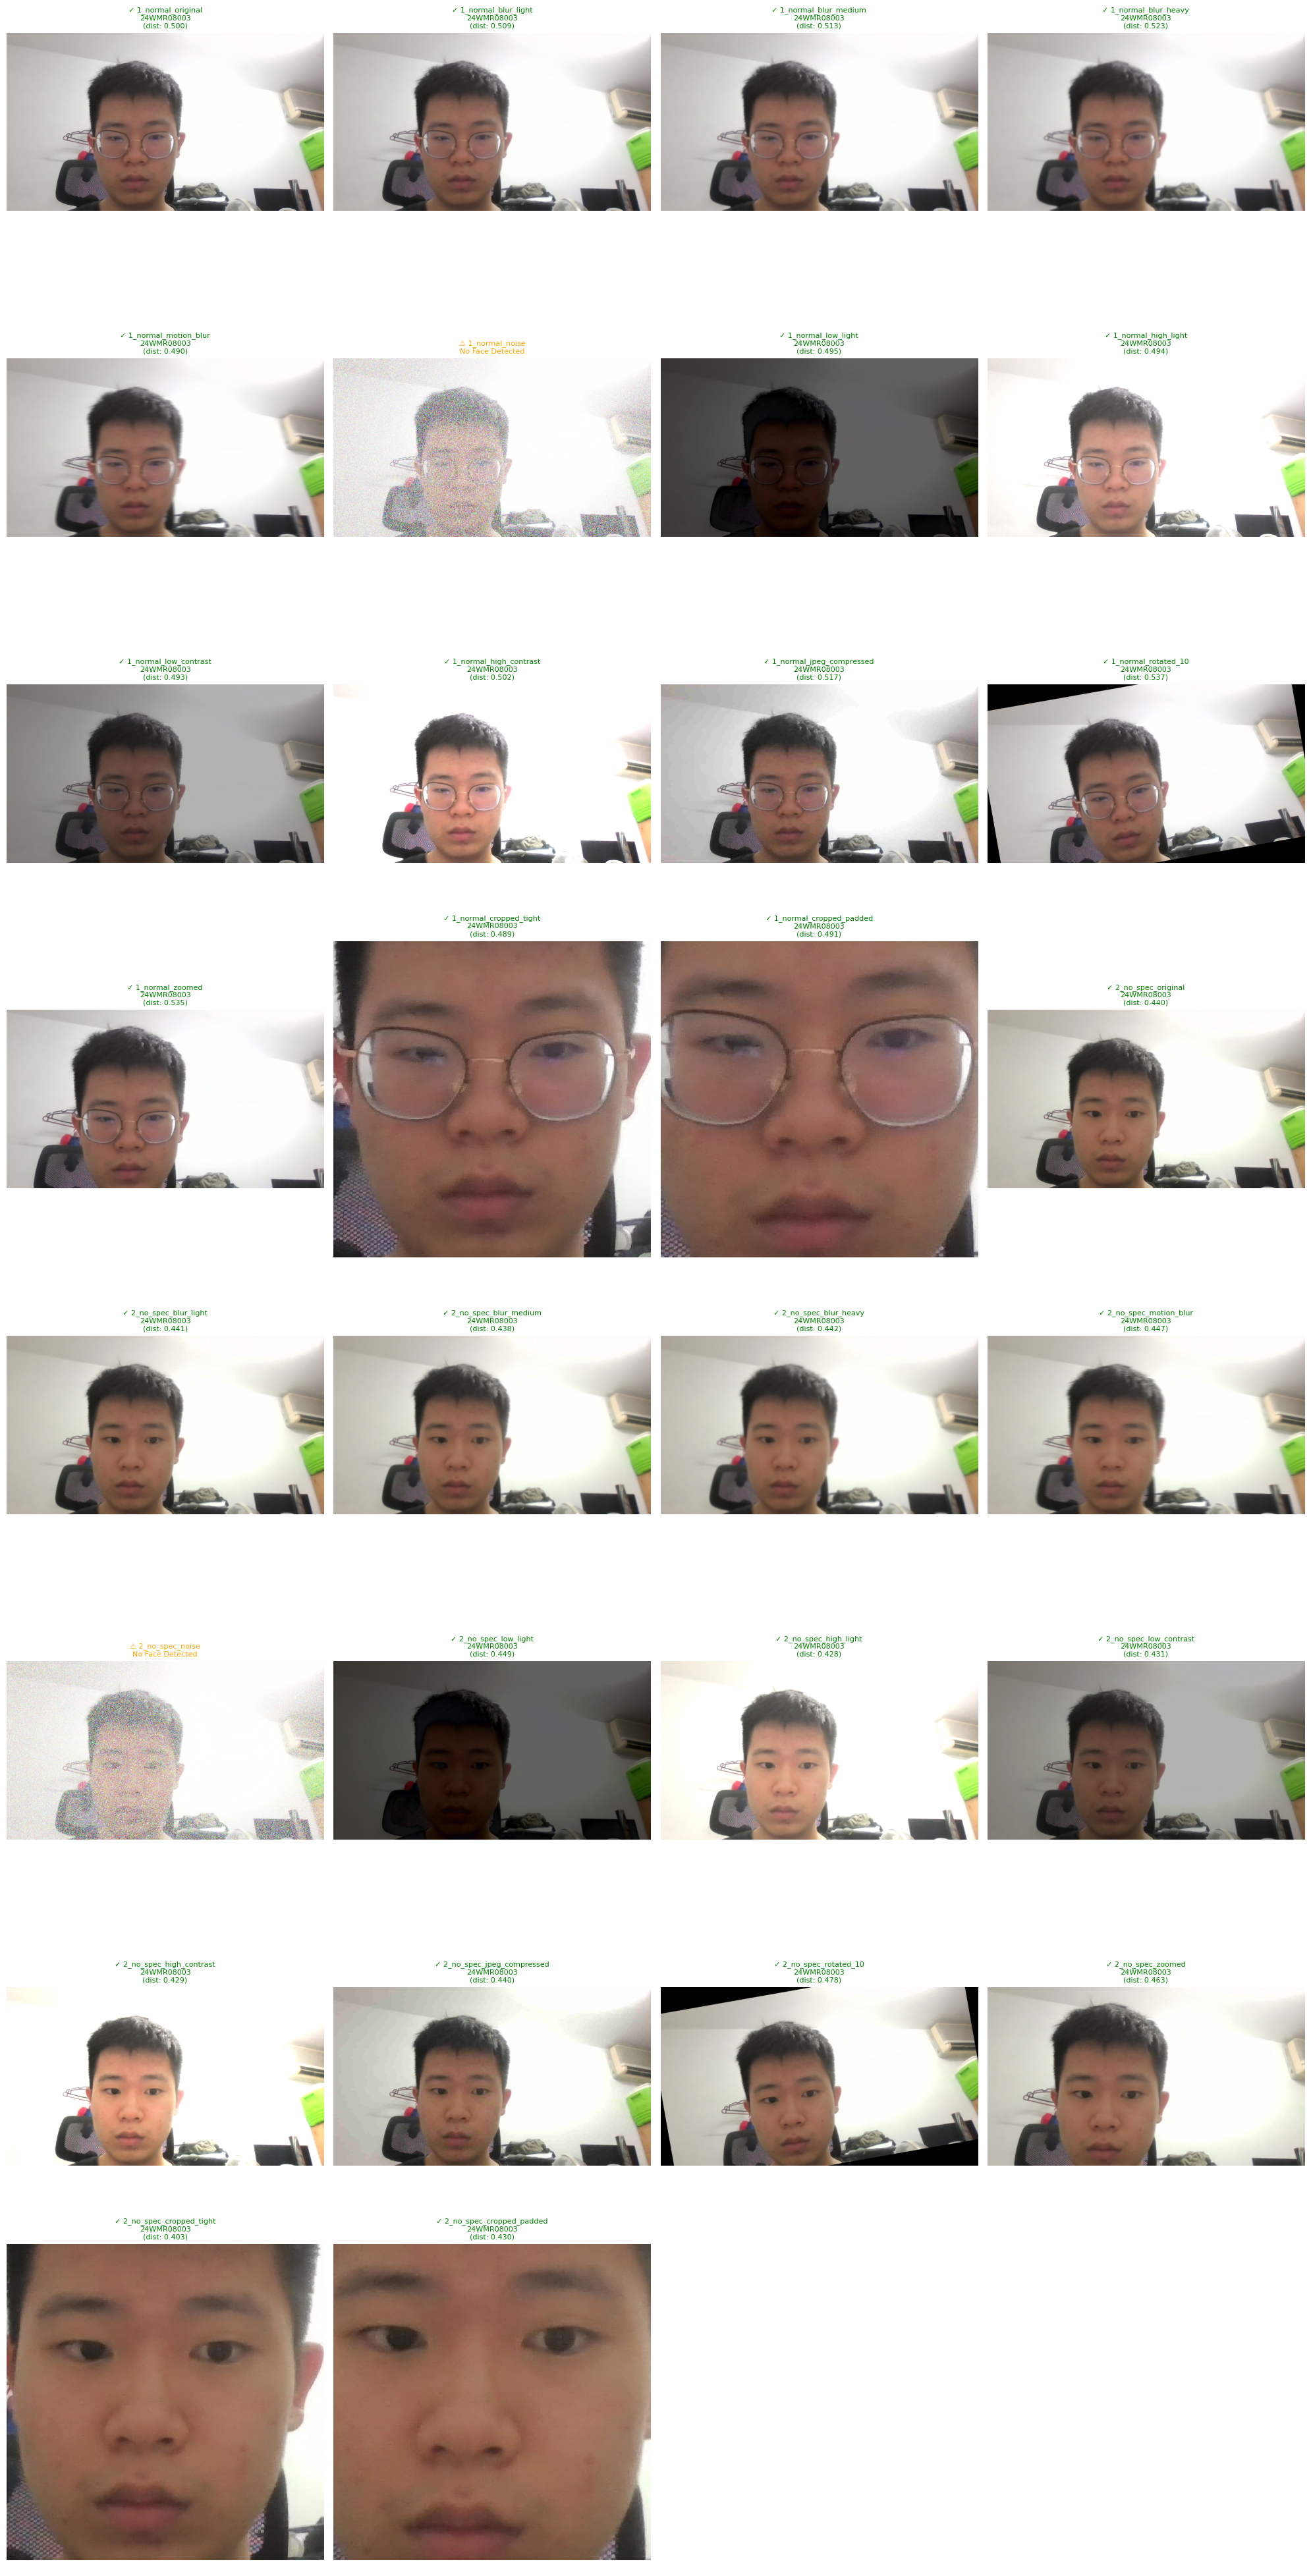

In [15]:
## Display Test Results with Images

def display_results_with_images(test_img_list, type_test, all_results, cols=4):
    """
    Display test images with recognition results
    """
    n_images = len(test_img_list)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()
    
    for idx, (img, name, result) in enumerate(zip(test_img_list, type_test, all_results)):
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        
        # Color title based on result
        if result['correct']:
            color = 'green'
            status = '✓'
        elif result['pred_id'] == 'No Face Detected':
            color = 'orange'
            status = '⚠'
        else:
            color = 'red'
            status = '✗'
        
        title = f"{status} {name}\n{result['pred_id']}"
        if result['distance'] is not None:
            title += f"\n(dist: {result['distance']:.3f})"
        
        axes[idx].set_title(title, fontsize=8, color=color)
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display results with images
display_results_with_images(augmented_test_img_list, augmented_type_test, all_results, cols=4)

In [16]:
import cv2 as cv
import numpy as np
import os
from typing import List, Dict, Optional
from deepface import DeepFace
from retinaface import RetinaFace
from sklearn.metrics.pairwise import cosine_similarity

class SimpleFaceRecognitionSystem:
    """
    Simple Face Recognition System - Register faces and recognize them
    """
    
    def __init__(self, 
                 model_name: str = "SFace",
                 confidence_threshold: float = 0.7,
                 similarity_threshold: float = 0.5):
        """
        Initialize the system
        """
        self.model_name = model_name
        self.confidence_threshold = confidence_threshold
        self.similarity_threshold = similarity_threshold
        
        # Storage for registered faces
        self.registered_embeddings = []
        self.registered_ids = []
        
        print(f"✅ Simple Face Recognition System initialized")
        print(f"   Model: {model_name}")
    
    def get_face_embedding(self, image: np.ndarray) -> Optional[np.ndarray]:
        """
        Extract face embedding from image
        
        Args:
            image: Input image (BGR format)
            
        Returns:
            Face embedding or None if failed
        """
        try:
            # Convert BGR to RGB for RetinaFace
            image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
            
            # Detect face using RetinaFace
            faces = RetinaFace.detect_faces(image_rgb)
            
            if not isinstance(faces, dict) or len(faces) == 0:
                print("❌ No face detected")
                return None
            
            # Get the best face (highest confidence)
            best_face_data = max(faces.values(), key=lambda x: x.get('score', 0))
            
            # Check confidence
            if best_face_data.get('score', 0) < self.confidence_threshold:
                print(f"❌ Face confidence too low: {best_face_data.get('score', 0):.3f}")
                return None
            
            # Extract face region
            x1, y1, x2, y2 = best_face_data['facial_area']
            face_img = image[y1:y2, x1:x2]
            
            # Ensure minimum size
            if face_img.shape[0] < 32 or face_img.shape[1] < 32:
                face_img = cv.resize(face_img, (112, 112))
            
            # Convert to RGB for DeepFace
            face_rgb = cv.cvtColor(face_img, cv.COLOR_BGR2RGB)
            
            # Extract embedding using DeepFace
            embedding_result = DeepFace.represent(
                img_path=face_rgb,
                model_name=self.model_name,
                detector_backend="skip",
                enforce_detection=False,
                align=True
            )
            
            if isinstance(embedding_result, list) and len(embedding_result) > 0:
                embedding = np.array(embedding_result[0]['embedding'])
                print(f"✅ Embedding extracted (confidence: {best_face_data.get('score', 0):.3f})")
                return embedding
            else:
                print("❌ Failed to extract embedding")
                return None
                
        except Exception as e:
            print(f"❌ Error extracting embedding: {e}")
            return None
    
    def register_face(self, image: np.ndarray, person_id: str) -> bool:
        """
        Register a face with an ID
        
        Args:
            image: Input image (BGR format)
            person_id: Unique identifier for the person
            
        Returns:
            True if registration successful, False otherwise
        """
        print(f"🔄 Registering face for ID: {person_id}")
        
        # Extract embedding
        embedding = self.get_face_embedding(image)
        
        if embedding is None:
            print(f"❌ Failed to register {person_id}")
            return False
        
        # Check if ID already exists
        if person_id in self.registered_ids:
            # Update existing registration
            idx = self.registered_ids.index(person_id)
            self.registered_embeddings[idx] = embedding
            print(f"✅ Updated registration for {person_id}")
        else:
            # Add new registration
            self.registered_embeddings.append(embedding)
            self.registered_ids.append(person_id)
            print(f"✅ Registered new face for {person_id}")
        
        return True
    
    def recognize_face(self, image: np.ndarray) -> Dict:
        """
        Recognize a face in the image
        
        Args:
            image: Input image (BGR format)
            
        Returns:
            Recognition result dictionary
        """
        print("🔄 Recognizing face...")
        
        # Check if any faces are registered
        if len(self.registered_embeddings) == 0:
            return {
                'success': False,
                'predicted_id': 'No registered faces',
                'similarity': 0.0,
                'confidence': 0.0
            }
        
        # Extract embedding from query image
        query_embedding = self.get_face_embedding(image)
        
        if query_embedding is None:
            return {
                'success': False,
                'predicted_id': 'No face detected',
                'similarity': 0.0,
                'confidence': 0.0
            }
        
        # Compare with all registered embeddings
        similarities = []
        for registered_embedding in self.registered_embeddings:
            # Compute cosine similarity
            sim = cosine_similarity(
                query_embedding.reshape(1, -1),
                registered_embedding.reshape(1, -1)
            )[0][0]
            similarities.append(sim)
        
        # Find best match
        best_idx = np.argmax(similarities)
        best_similarity = similarities[best_idx]
        
        # Check if similarity meets threshold
        if best_similarity >= self.similarity_threshold:
            predicted_id = self.registered_ids[best_idx]
            success = True
            message = f"Recognized as {predicted_id}"
        else:
            predicted_id = "Unknown"
            success = False
            message = f"No match found (best similarity: {best_similarity:.3f})"
        
        print(f"✅ {message}")
        
        return {
            'success': success,
            'predicted_id': predicted_id,
            'similarity': best_similarity,
            'confidence': best_similarity,
            'all_similarities': similarities,
            'message': message
        }
    
    def get_registered_count(self) -> int:
        """Get number of registered faces"""
        return len(self.registered_ids)
    
    def get_registered_ids(self) -> List[str]:
        """Get list of registered IDs"""
        return self.registered_ids.copy()
    
    def remove_face(self, person_id: str) -> bool:
        """
        Remove a registered face
        
        Args:
            person_id: ID to remove
            
        Returns:
            True if removed successfully, False if not found
        """
        if person_id in self.registered_ids:
            idx = self.registered_ids.index(person_id)
            self.registered_embeddings.pop(idx)
            self.registered_ids.pop(idx)
            print(f"✅ Removed {person_id}")
            return True
        else:
            print(f"❌ {person_id} not found")
            return False

# Helper function
def load_img_from_folder(folder_path: str):
    """Load images from folder"""
    import os
    
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    image_list = []
    filename_list = []

    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        return [], []

    for filename in os.listdir(folder_path):
        ext = os.path.splitext(filename)[1].lower()
        if ext in valid_extensions:
            img_path = os.path.join(folder_path, filename)
            img = cv.imread(img_path)
            if img is not None:
                image_list.append(img)
                filename_list.append(os.path.splitext(filename)[0])
    
    return image_list, filename_list

# Example usage
def test_simple_system():
    """Test the simple face recognition system"""
    print("🧪 Testing Simple Face Recognition System")
    print("=" * 50)
    
    # Initialize system
    system = SimpleFaceRecognitionSystem(
        model_name="SFace",
        confidence_threshold=0.7,
        similarity_threshold=0.5
    )
    
    # Register faces from a folder
    print("\n📁 Registering faces from 'Image' folder...")
    images, ids = load_img_from_folder("Image")
    
    registered_count = 0
    for image, person_id in zip(images, ids):
        if system.register_face(image, person_id):
            registered_count += 1
    
    print(f"\n✅ Registered {registered_count}/{len(images)} faces")
    print(f"Registered IDs: {system.get_registered_ids()}")
    
    # Test recognition on test images
    print("\n🔍 Testing recognition...")
    test_images, test_names = load_img_from_folder("test_set")
    
    if len(test_images) > 0:
        for i, (test_img, test_name) in enumerate(zip(test_images[:3], test_names[:3])):  # Test first 3
            print(f"\nTesting image: {test_name}")
            result = system.recognize_face(test_img)
            print(f"Result: {result['predicted_id']} (similarity: {result['similarity']:.3f})")
    
    return system

system = test_simple_system()

ModuleNotFoundError: No module named 'deepface'

In [ ]:
try:
    DeepFace.represent("test.jpg", model_name="SFace")
except:
    pass  # Models will download automatically